# 03 - Modeling and Evaluation

In the previous notebook, I used K-Means to create Steam user segments based on user-level behavioral features and saved them in `clustered_users.csv`.

In this notebook, I use supervised learning models to check how well these discovered segments can be reproduced from the same behavioral features.  

These labels are not true external labels from the original dataset. They are discovered segments created by K-Means.

The purpose is to make the segments more interpretable and operational.

## 1. Import libraries and project paths

I use common classification models from scikit-learn and evaluate them with accuracy, precision, recall, F1-score, and confusion matrix.

In [15]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

## 2. Load clustered user-level data

The clustered user table was created in the previous notebook. It contains the user-level behavioral features together with the K-Means cluster assigned to each user.

The cluster labels are not original labels from the dataset. They are discovered segments created by K-Means and are used here as a target-like variable for model comparison and interpretation.

In [16]:
clustered_users_path = PROCESSED_DATA_DIR / "clustered_users.csv"

clustered_users = pd.read_csv(clustered_users_path)
clustered_users.head()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio,cluster
0,5250,225.5,8.351852,144.0,21,21,27,10.738095,0.777778,1
1,76767,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857,0
2,86540,255.0,2.628866,113.0,82,82,97,3.109756,0.845361,1
3,103360,0.0,0.000000,0.0,10,10,10,0.000000,1.000000,1
4,144736,0.1,0.011111,0.1,8,8,9,0.012500,0.888889,1


In [17]:
clustered_users.shape
clustered_users["cluster"].value_counts().sort_index()

cluster
0    9355
1    2429
2     244
3     365
Name: count, dtype: int64

The shape and cluster distribution confirms that the modeling notebook starts from the user-level clustered dataset rather than the raw interaction-level dataset.

## 3. Add interpreted cluster names

The numeric cluster labels are easier to understand when they are connected to the behavioral profiles interpreted in the clustering notebook. These names are not original dataset labels; they are interpretation labels based on the cluster summary statistics.

In [18]:
cluster_names = {
    0: "Moderate / Regular Players",
    1: "Low Engagement / Mostly Purchasers",
    2: "Broad Library / Collectors",
    3: "Focused Heavy Players"
}

clustered_users["cluster_name"] = clustered_users["cluster"].map(cluster_names)

clustered_users[["user_id", "cluster", "cluster_name"]].head()

,user_id,cluster,cluster_name
0,5250,1,Low Engagement / Mostly Purchasers
1,76767,0,Moderate / Regular Players
2,86540,1,Low Engagement / Mostly Purchasers
3,103360,1,Low Engagement / Mostly Purchasers
4,144736,1,Low Engagement / Mostly Purchasers


These cluster names are used only for interpretation. The supervised models still use the numeric `cluster` column, but the names help connect the model results back to user behavior.

## 4. Prepare features and target-like variable

The input features are the same user-level behavioral variables used during clustering. The target-like variable is the K-Means cluster label.

This setup helps evaluate whether the discovered user segments can be reproduced and explained using supervised learning models.

In [19]:
feature_columns = [
    "total_hours",
    "avg_hours",
    "max_hours",
    "unique_games",
    "purchase_count",
    "total_interactions",
    "hours_per_game",
    "purchase_ratio"
]

X = clustered_users[feature_columns]
y = clustered_users["cluster"]

X.head()

,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
0,225.5,8.351852,144.0,21,21,27,10.738095,0.777778
1,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857
2,255.0,2.628866,113.0,82,82,97,3.109756,0.845361
3,0.0,0.000000,0.0,10,10,10,0.000000,1.000000
4,0.1,0.011111,0.1,8,8,9,0.012500,0.888889


In [20]:
y.value_counts().sort_index()

cluster
0    9355
1    2429
2     244
3     365
Name: count, dtype: int64

The `user_id` column is not used as a model input because it is only an identifier and does not describe user behavior. The `cluster_name` column is also not used as a model input because it is only an interpretation label added for readability.

## 5.Train-test split

I split the data into training and test sets. Since the cluster sizes are not equal, I use stratified splitting to keep the cluster distribution similar in both sets.

The test set will be used as the final hold-out evaluation set.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=570,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9914, 8)
X_test: (2479, 8)
y_train: (9914,)
y_test: (2479,)


In [22]:
train_cluster_distribution = y_train.value_counts(normalize=True).sort_index()
test_cluster_distribution = y_test.value_counts(normalize=True).sort_index()

split_distribution = pd.DataFrame({
    "Train Distribution": train_cluster_distribution,
    "Test Distribution": test_cluster_distribution
})

split_distribution

,Train Distribution,Test Distribution
cluster,,
0,0.754892,0.754740
1,0.195985,0.196047
2,0.019669,0.019766
3,0.029453,0.029447


The train and test cluster distributions are very similar because I used stratified splitting. This is important because the cluster sizes are not equal, and the smaller clusters should still be represented in both sets.

## 6. Define models

I compare a simple baseline model with several supervised classification models. The goal is not to predict an external real-world label, but to check how well the K-Means segment labels can be reproduced and explained.

Logistic Regression and KNN are used with scaling because they are sensitive to feature scale. Tree-based models are kept without scaling because they split the data based on feature thresholds.

In [35]:
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent", random_state=570),

    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=570))
    ]),

    "KNN": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=570),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=570
    ),

    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        random_state=570
    )
}

## 7. Cross-validation check

In addition to the train-test split, I use stratified cross-validation as a stability check. This helps show whether model performance is consistent across different folds.

Since the cluster labels are imbalanced, I use StratifiedKFold to keep the cluster distribution similar in each fold.

In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=570
)

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1_weighted"
    )

    cv_results.append({
        "Model": model_name,
        "CV Mean F1": scores.mean(),
        "CV Std F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("CV Mean F1", ascending=False)

,Model,CV Mean F1,CV Std F1
5,Gradient Boosting,0.997089,0.001651
1,Logistic Regression,0.996209,0.001309
4,Random Forest,0.995311,0.001187
2,KNN,0.994423,0.001128
3,Decision Tree,0.991611,0.003289
0,Dummy Classifier,0.649414,0.000202


The cross-validation results show that all supervised models perform much better than the Dummy Classifier baseline. This means that the selected behavioral features contain enough information to reproduce the K-Means segment labels.

The very high F1 scores should be interpreted carefully. The target variable in this notebook is not an external ground-truth label. It is the `cluster` column created by K-Means:

`y = clustered_users["cluster"]`

Since these cluster labels were created from the same user-level behavioral features, high supervised model scores are expected. These results do not mean that the models predict real user types with almost perfect accuracy. Instead, they show that the K-Means segments are consistent with the selected features and can be reproduced by supervised models.

Cross-validation is used here to check whether the model performance is stable across different folds. Since the cluster sizes are imbalanced, I use StratifiedKFold so that each fold keeps a similar cluster distribution. The low CV standard deviation values show that the model performance does not change much across folds.

Gradient Boosting gives the highest mean F1 score, but the differences between the main supervised models are very small. Therefore, the main takeaway is not that one model is clearly superior, but that the discovered clusters are strongly explained by the behavioral feature set.

## 9. Train and evaluate models

For each model, I calculate accuracy, precision, recall, and F1-score on the test set.
Since this is a multi-class problem, I use weighted averages for precision, recall, and F1-score.

In [24]:
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Dummy Classifier,0.754740,0.569632,0.754740,0.649250
1,Logistic Regression,0.996370,0.996375,0.996370,0.996355
2,KNN,0.993546,0.993553,0.993546,0.993520
3,Decision Tree,0.990722,0.990632,0.990722,0.990483
4,Random Forest,0.995966,0.995949,0.995966,0.995934
5,Gradient Boosting,0.995966,0.995965,0.995966,0.995955


In [25]:
results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.996370,0.996375,0.996370,0.996355
5,Gradient Boosting,0.995966,0.995965,0.995966,0.995955
4,Random Forest,0.995966,0.995949,0.995966,0.995934
2,KNN,0.993546,0.993553,0.993546,0.993520
3,Decision Tree,0.990722,0.990632,0.990722,0.990483
0,Dummy Classifier,0.754740,0.569632,0.754740,0.649250


## 10. Model comparison chart

A simple bar chart makes it easier to compare the models.

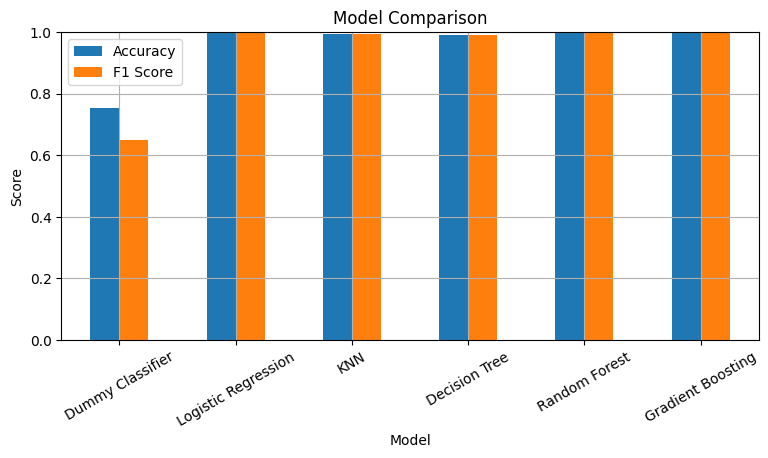

In [26]:
results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(9, 4),
    title="Model Comparison",
    ylabel="Score",
    ylim=(0, 1),
    grid=True,
    rot=30
)

plt.show()

## 11. Confusion matrix for Decision Tree

I focus on the Decision Tree because it is easier to interpret than more complex models.

In [27]:
tree_model = models["Decision Tree"]
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

cm = confusion_matrix(y_test, tree_pred)
cm

array([[1868,    0,    1,    2],
       [   5,  481,    0,    0],
       [   2,    0,   47,    0],
       [  12,    1,    0,   60]])

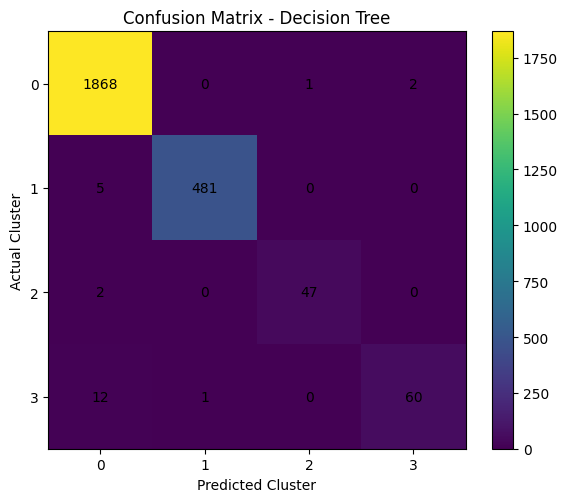

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Confusion Matrix - Decision Tree")
ax.set_xlabel("Predicted Cluster")
ax.set_ylabel("Actual Cluster")

ax.set_xticks(range(len(cm)))
ax.set_yticks(range(len(cm)))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 12. Classification report

The classification report gives precision, recall, and F1-score for each cluster separately.

In [29]:
print(classification_report(y_test, tree_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1871
           1       1.00      0.99      0.99       486
           2       0.98      0.96      0.97        49
           3       0.97      0.82      0.89        73

    accuracy                           0.99      2479
   macro avg       0.98      0.94      0.96      2479
weighted avg       0.99      0.99      0.99      2479



## 13. Decision Tree feature importance

Feature importance helps show which behavioral variables are most useful for explaining the cluster labels.

In [30]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
7,purchase_ratio,0.762628
5,total_interactions,0.090501
1,avg_hours,0.081997
2,max_hours,0.046394
6,hours_per_game,0.009282
0,total_hours,0.007520
4,purchase_count,0.001513
3,unique_games,0.000165


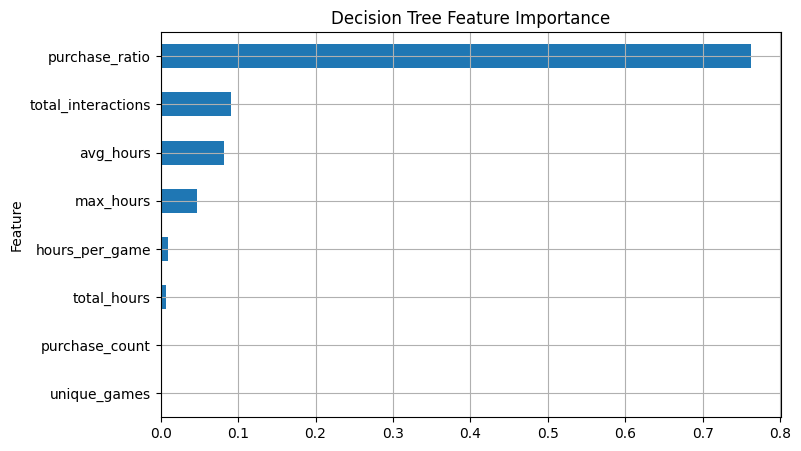

In [31]:
feature_importance.sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(8, 5),
    title="Decision Tree Feature Importance",
    legend=False,
    grid=True
)

plt.show()

## 14. Visualize the Decision Tree

A shallow tree is easier to read and helps explain the main decision rules behind the clusters.

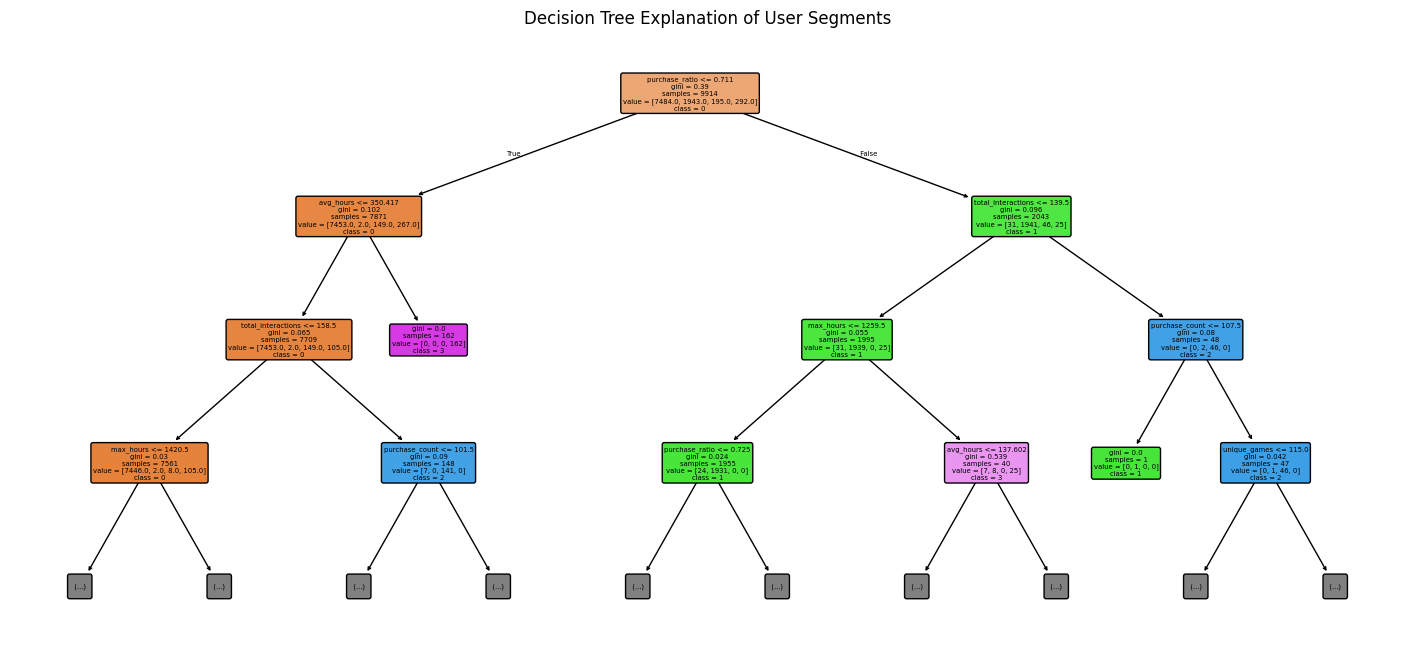

In [32]:
plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=feature_columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Explanation of User Segments")
plt.show()

## 15. Save model results

The model comparison table is saved so that it can be reused in the Streamlit dashboard.

In [33]:
model_results_path = PROCESSED_DATA_DIR / "model_results.csv"

results_df.to_csv(model_results_path, index=False)

model_results_path

PosixPath('/Users/ismailozcan/Desktop/ds570-final-project/data/processed/model_results.csv')

## 16. Interpretation note

The high performance of some models should be interpreted carefully.

The cluster labels are created from the same behavioral features using K-Means.  
Therefore, this modeling task does not measure prediction of an external real-world label.  
Instead, it checks whether the discovered user segments can be reproduced and explained with supervised learning models.

This is useful because it turns the cluster results into more understandable behavioral rules.

## 17. Main observations from modeling

At this stage:

- A baseline classifier was included.
- Several classification models were compared.
- Weighted precision, recall, and F1-score were used for evaluation.
- Decision Tree was used to explain the cluster labels.
- Feature importance helped identify the behavioral variables behind the segments.
- Model results were saved for the dashboard.

The next step is to add an additional recommendation-oriented analysis and then build the Streamlit dashboard.